In [18]:
# Import required libraries
import sys
from pathlib import Path

_repo_root = Path().resolve()
sys.path.insert(0, str(_repo_root / 'app'))

from PIL import Image, ImageDraw, ImageFont
import qrcode
from IPython.display import display
from services.label_service import generate_label_image
import secrets

In [ ]:
# # Copy of the generate_label_image function from api.py
# def generate_label_image(repair_data):
#     """
#     Generate a label image for SLP 650
#     SLP 650 native resolution: 203 DPI
#     Label size: 406 x 224 pixels (51mm x 28mm)
#     """
#     # Create image (51mm x 28mm at 203 DPI)
#     width, height = 406, 224
#     img = Image.new('RGB', (width, height), 'white')
#     draw = ImageDraw.Draw(img)
    
#     # Use default font (or load custom font if available)
#     try:
#         font_large = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 24)
#         font_medium = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 16)
#         font_small = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 12)
#     except:
#         font_large = ImageFont.load_default()
#         font_medium = ImageFont.load_default()
#         font_small = ImageFont.load_default()
    
#     # Draw date (top left)
#     draw.text((10, 10), f"{repair_data['datum']}", fill='black', font=font_medium)
    
#     # Draw name with text wrapping
#     name = f"{repair_data.get('vorname', '')} {repair_data.get('nachname', '')}".strip()
#     if name:
#         # Max width for text (leave space for QR code on right)
#         max_text_width = width - 160  # 406 - 145(qr position) - 15(margin) = 246
#         words = name.split()
#         lines = []
#         current_line = []
        
#         for word in words:
#             test_line = ' '.join(current_line + [word])
#             bbox = draw.textbbox((0, 0), test_line, font=font_large)
#             line_width = bbox[2] - bbox[0]
            
#             if line_width <= max_text_width:
#                 current_line.append(word)
#             else:
#                 if current_line:
#                     lines.append(' '.join(current_line))
#                 current_line = [word]
        
#         if current_line:
#             lines.append(' '.join(current_line))
        
#         # Draw lines (max 3 lines to fit in space)
#         y_position = 40
#         for i, line in enumerate(lines[:3]):
#             draw.text((10, y_position), line, fill='black', font=font_large)
#             y_position += 30
    
#     # Draw device type
#     device = repair_data.get('geraet_art', '')
#     if device:
#         # Calculate position based on how many name lines were drawn
#         device_y = 40 + (len(lines[:3]) * 30) if name else 70
#         draw.text((10, device_y), device[:25], fill='black', font=font_medium)
    
#     # Generate QR code (right side)
#     qr_url = f"http://repaircafe/edit/{repair_data['qr_token']}"
#     qr = qrcode.QRCode(version=1, box_size=3, border=1)
#     qr.add_data(qr_url)
#     qr.make(fit=True)
#     qr_img = qr.make_image(fill_color="black", back_color="white")
    
#     # Resize QR code to fit label (make it about 180x180 pixels)
#     qr_img = qr_img.resize((140, 140))
    
#     # Paste QR code on right side
#     qr_x = width - 145
#     img.paste(qr_img, (qr_x, 10))
    
#     # Draw repair ID centered below QR code
#     id_text = f"#{repair_data['id']}"
#     bbox = draw.textbbox((0, 0), id_text, font=font_large)
#     text_width = bbox[2] - bbox[0]
#     id_x = qr_x + (140 - text_width) // 2
#     draw.text((id_x, 170), id_text, fill='black', font=font_large)
    
#     # Add logo in bottom left corner (64x64 pixels)
#     # Active logo lives in data/logo.png; fall back to the bundled static default.
#     _repo_root = Path().resolve()
#     logo_path = _repo_root / 'data' / 'logo.png'
#     if not logo_path.exists():
#         logo_path = _repo_root / 'app' / 'static' / 'logo.jpg'
#     try:
#         logo = Image.open(logo_path)
#         logo = logo.resize((64, 64))
#         logo_x = 10
#         logo_y = height - 64 - 10  # 10 pixels from bottom
#         img.paste(logo, (logo_x, logo_y))
        
#         # Add text next to the logo
#         text_x = logo_x + 64 + 5  # 5 pixels spacing after logo
#         text_y = logo_y + 26  # Center text vertically with logo
#         draw.text((text_x, text_y), "Repair Café", fill='black', font=font_small)
#     except Exception as e:
#         print(f"Warning: Could not load logo: {e}")
    
#     return img

## Test with Sample Data

Create a sample repair record and generate the label image.

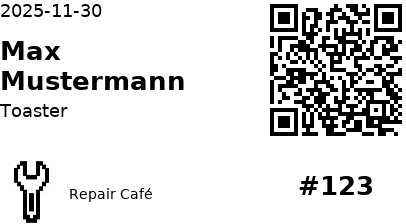

In [19]:
# Sample repair data
sample_repair = {
    'id': 123,
    'datum': '2025-11-30',
    'vorname': 'Max',
    'nachname': 'Mustermann',
    'telefon': '+49 123 456789',
    'email': 'max@example.com',
    'reparatur_art': 'Elektro',
    'geraet_art': 'Toaster',
    'defekt_besch': 'Heizt nicht mehr',
    'offen': True,
    'qr_token': secrets.token_hex(16),
}

# Generate and display the label
label = generate_label_image(sample_repair, base_url="http://repaircafe", org_name="Repair Café")
display(label)

## Test with Custom Data

Modify the values below to test different label layouts.

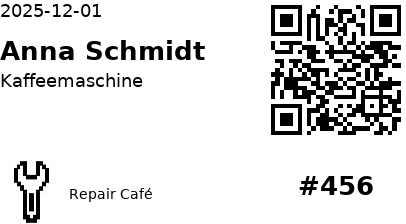

In [9]:
# Custom repair data - modify these values
custom_repair = {
    'id': 456,
    'datum': '2025-12-01',
    'vorname': 'Anna',
    'nachname': 'Schmidt',
    'geraet_art': 'Kaffeemaschine',
    'offen': False,
    'qr_token': secrets.token_hex(16)
}

# Generate and display
label = generate_label_image(custom_repair)
display(label)

## Test with Long Text

Test how the label handles longer names and device types.

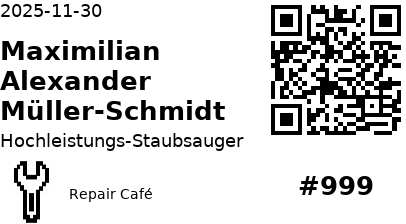

In [10]:
# Test with long text
long_text_repair = {
    'id': 999,
    'datum': '2025-11-30',
    'vorname': 'Maximilian Alexander',
    'nachname': 'Müller-Schmidt',
    'geraet_art': 'Hochleistungs-Staubsauger',
    'qr_token': secrets.token_hex(16)
}

label = generate_label_image(long_text_repair)
display(label)

## Save Label to File

Optionally save the generated label as a PNG file for inspection.

In [7]:
# Save the last generated label
output_path = '/workspaces/repaircafepage/test_label.png'
label.save(output_path)
print(f"Label saved to: {output_path}")
print(f"Image size: {label.size[0]}x{label.size[1]} pixels")

Label saved to: /workspaces/repaircafepage/test_label.png
Image size: 406x224 pixels
